# Validating the aging curves

`GAM.ipynb` fits the curves and `delta_method.ipynb` scores them against naive baselines. Neither
asks whether the curves themselves are trustworthy. This notebook does, in three steps:

1. **Is test MAE even measuring the curve?** (Largely not.)
2. **Where is the curve wrong?** Residuals broken out by age, rather than averaged over it.
3. **Is the peak age a property of the data, or of a modelling convention?** (Partly the latter.)

The analysis code is in `mlb_aging.diagnostics`; what stays here is the narrative and the plots.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from mlb_aging.dataset import build_training_frame, load_data
from mlb_aging.diagnostics import residuals_by_age
from mlb_aging.evaluate import evaluate
from mlb_aging.features import generate_test_data
from mlb_aging.gam import CURVE_POINTS, aging_curve, fit_gam
from mlb_aging.ipw import fit_ipw_weights
from mlb_aging.baselines import run_baselines
from mlb_aging.metrics import METRICS, get_metric
from mlb_aging.pipeline import compare_baselines
from mlb_aging.plots import plot_residuals_by_age

## 1. Test MAE is a weak instrument for curve quality

The baseline ladder makes the point on its own. `persistence` predicts "last season, unchanged" —
it contains **no age term at all**, no curve, no aging information of any kind. If test MAE
measured how good an aging curve is, that arm should be far behind.

In [2]:
print(compare_baselines(get_metric("Def")).summary())

Def  (n_test=887, scored PA-weighted)
  model                MAE   vs delta_lag
  persistence       4.5881          -1.2%
  delta_curve       6.5941         -45.5%
  delta_lag         4.5319              —
  gam               4.7541          -4.9%
  gam_ipw           4.6579          -2.8%


`persistence` beats the GAM and lands within about 1% of the best arm. A score that a model
containing no aging signal nearly wins cannot rank aging curves — it is dominated by how well the
*level* is predicted, which is mostly talent and persistence.

That does not make MAE useless; it makes it the wrong instrument for this particular question. The
rest of this notebook uses held-out data differently.

## 2. Where is the curve wrong?

Averaged over the whole test set, a systematic error in the decline phase vanishes — over- and
under-prediction at different ages cancel. Broken out by age it becomes visible and locatable.

If the curve's shape is right, mean residuals are flat in age. A slope means the curve is wrong in
a specific place, and the sign says which way.

In [3]:
FITS = {}          # (metric, spec) -> fitted GAM, reused throughout the notebook
FRAMES = {}        # metric -> (train frame, test frame, delta_lag MAE)

for name in METRICS:
    spec = get_metric(name)
    train_data, test_data = load_data(spec)
    train_df = build_training_frame(train_data, spec)
    test_df = generate_test_data(train_df, test_data, spec.target_col)
    delta_lag = run_baselines(spec)[0]["delta_lag"].test_mae
    FRAMES[name] = (train_df, test_df, delta_lag)

    ipw_weights = fit_ipw_weights(train_df, spec)["ipw_final_weight"].values
    for model_spec in ("tensor", "age_only"):
        FITS[name, model_spec, False] = fit_gam(train_df, spec, model_spec=model_spec)
        FITS[name, model_spec, True] = fit_gam(
            train_df, spec, weights=ipw_weights, model_spec=model_spec
        )

print(f"{len(FITS)} models fitted once and reused below")

20 models fitted once and reused below


wRC+ — uncorrected
  residual = actual − predicted, PA-weighted; negative means the curve over-predicts
     age bin      n   mean resid        sd
    (20, 27]     95       -0.820    27.415
    (27, 29]    182       -1.744    24.240
    (29, 31]    241       -1.797    27.281
    (31, 33]    196       -5.300    26.958
    (33, 35]    108       -4.651    25.443
    (35, 41]     65      -16.048    30.228
  youngest → oldest bend: -15.228

wRC+ — IPW-corrected
  residual = actual − predicted, PA-weighted; negative means the curve over-predicts
     age bin      n   mean resid        sd
    (20, 27]     95       -0.484    27.431
    (27, 29]    182       -1.245    24.180
    (29, 31]    241       -0.970    27.223
    (31, 33]    196       -4.018    26.897
    (33, 35]    108       -2.830    25.365
    (35, 41]     65      -13.279    30.000
  youngest → oldest bend: -12.794


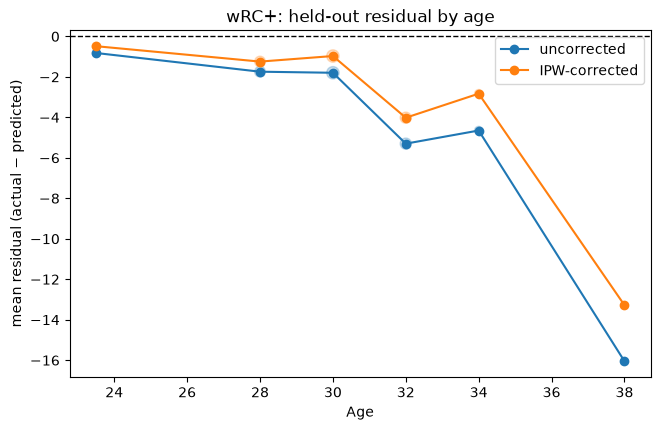

In [4]:
spec = get_metric("wRC+")
train_df, test_df, _ = FRAMES["wRC+"]

plain = residuals_by_age(test_df, spec, FITS["wRC+", "tensor", False], label="uncorrected")
corrected = residuals_by_age(test_df, spec, FITS["wRC+", "tensor", True], label="IPW-corrected")
print(plain.summary())
print()
print(corrected.summary())

plot_residuals_by_age(plain, corrected)
plt.show()

Residual is *actual − predicted*, so negative means the curve **over-predicts**. The line is not
flat: it falls steadily with age and collapses in the oldest bin. The model is too optimistic about
old players, and increasingly so — the decline phase is fitted too shallow.

That is exactly what survivorship bias produces, and the IPW arm moves every point in the right
direction, by more at older ages. But it closes only about a sixth of the gap in the oldest bin.
The correction has the right shape and the wrong size.

In [5]:
rows = []
for name in METRICS:
    spec = get_metric(name)
    _, test_df, _ = FRAMES[name]
    for label, ipw in (("uncorrected", False), ("IPW", True)):
        profile = residuals_by_age(test_df, spec, FITS[name, "tensor", ipw])
        rows.append({"metric": name, "arm": label,
                     "young bin": round(profile.table["mean_resid"].iloc[0], 3),
                     "old bin": round(profile.table["mean_resid"].iloc[-1], 3),
                     "bend": round(profile.bends_with_age, 3)})
pd.DataFrame(rows)

,metric,arm,young bin,old bin,bend
0,OPS,uncorrected,-0.006,-0.057,-0.050
1,OPS,IPW,-0.005,-0.046,-0.041
2,wRC+,uncorrected,-0.820,-16.048,-15.228
3,wRC+,IPW,-0.484,-13.279,-12.794
4,Def,uncorrected,-1.480,-0.468,1.012
5,Def,IPW,-1.415,-0.937,0.478
6,Spd,uncorrected,-0.558,-0.238,0.319
7,Spd,IPW,-0.545,-0.183,0.362
8,WAR,uncorrected,-0.238,-1.172,-0.933
9,WAR,IPW,-0.192,-1.019,-0.826


Def is the exception, and it is informative. Its residual is a roughly constant offset at every
age rather than a bend — a **level** problem, not a shape problem. The Def aging curve's shape
survives out of sample; what fails is a constant gap between the training era and 2021–2025, which
points at the metric's own calibration rather than at the model.

## 3. Is the peak age a property of the data?

`aging_curve` has to pin every non-age feature to trace a curve. For `experience` it pins
`age − 20`: one coherent career, a player who debuted at 20 and never missed a season.

That is the right *kind* of convention — tying experience to age is what makes the curve a
trajectory rather than a cross-section of different players. But the debut age inside it is a free
choice, and `te(0, 2)` makes age and experience interact, so the choice has consequences.

In [6]:
def peak_for_debut(name, debut, model_spec="tensor"):
    """Trace the curve for a player who debuted at `debut`, and return its peak."""
    spec = get_metric(name)
    train_df, _, _ = FRAMES[name]
    gam = FITS[name, model_spec, False]
    lag_means = train_df.groupby("Age")[spec.lag_col].mean()

    xx = gam.generate_X_grid(term=0, n=CURVE_POINTS)
    ages = xx[:, 0]
    reference = spec.curve_reference
    if reference == "train_mean":
        xx[:, 1] = np.mean(train_df[spec.target_col])
    elif reference is not None:
        xx[:, 1] = reference
    floored = np.floor(ages)
    xx[:, 2] = floored - float(debut)
    xx[:, 3] = [lag_means[age] for age in floored]

    curve = pd.Series(gam.predict(xx), index=ages).groupby(level=0).first().sort_index()
    curve = curve[curve.index >= debut]      # the career does not exist before its debut
    return round(float(curve.idxmax()), 2)

DEBUTS = [20, 21, 22, 23, 24]
peaks = pd.DataFrame(
    {f"debut {d}": [peak_for_debut(n, d) for n in METRICS] for d in DEBUTS},
    index=list(METRICS),
)

train_df = FRAMES["WAR"][0]
debut_age = (train_df.assign(d=train_df.Age - train_df.experience)
             .groupby("IDfg")["d"].min().round().value_counts().sort_index())
print("players by debut age:")
print(debut_age.head(8).to_string())
peaks

players by debut age:
d
20.0     43
21.0    121
22.0    235
23.0    352
24.0    428
25.0    380
26.0    256
27.0    173


,debut 20,debut 21,debut 22,debut 23,debut 24
OPS,26.00,26.00,27.01,27.01,27.31
wRC+,26.00,26.00,27.01,27.01,27.77
Def,23.02,24.01,25.01,25.01,26.00
Spd,21.00,21.00,22.01,23.02,24.01
WAR,25.01,26.00,26.00,27.01,27.01


The peak tracks the assumed debut age almost one-for-one — and the debut age the published
curves assume, 20, is the **rarest** in the data. Roughly 43 players debuted at 20; the modal
debut is 24. Traced the typical way, OPS peaks at 27.3, wRC+ at 27.8 and WAR at 27.0.

Def swings three full years, from 23 to 26. Together with its flat residual profile above, that is
strong evidence Def's peak is not a locatable quantity in this data.

## 4. Removing the tensor removes the ambiguity

Standard practice does not put experience in the model at all. The GAM approach in Baseball
Prospectus's *"The Delta Method, Revisited"* and the FanGraphs Sabermetrics Library both smooth on
age and control for the player's career average performance, handling experience implicitly
through that control — precisely because age, experience and service time are near-collinear.

`model_spec="age_only"` does the same: `s(0) + s(1) + s(3)` instead of `te(0, 2) + s(1) + s(3)`.
With no experience term, the traced curve no longer depends on the debut assumption.

In [7]:
rows = []
for name in METRICS:
    spec = get_metric(name)
    train_df, test_df, delta_lag = FRAMES[name]
    for model_spec in ("tensor", "age_only"):
        gam = FITS[name, model_spec, False]
        mae = evaluate(test_df, spec, gam)
        mae_ipw = evaluate(test_df, spec, FITS[name, model_spec, True])
        rows.append({
            "metric": name, "spec": model_spec,
            "peak": round(aging_curve(gam, train_df, spec).peak_age, 2),
            "peak @debut24": peak_for_debut(name, 24, model_spec),
            "test MAE": round(mae, 4),
            "vs delta_lag": f"{100 * (1 - mae / delta_lag):+.1f}%",
            "+IPW": f"{100 * (1 - mae_ipw / delta_lag):+.1f}%",
        })
pd.DataFrame(rows)

,metric,spec,peak,peak @debut24,test MAE,vs delta_lag,+IPW
0,OPS,tensor,26.00,27.31,0.0752,+7.5%,+8.8%
1,OPS,age_only,26.99,26.99,0.0755,+7.1%,+8.7%
2,wRC+,tensor,26.00,27.77,19.7154,+6.2%,+7.4%
3,wRC+,age_only,26.99,26.99,19.7730,+6.0%,+7.3%
4,Def,tensor,23.02,26.00,4.7541,-4.9%,-2.8%
5,Def,age_only,21.99,24.01,4.8156,-6.3%,-4.3%
6,Spd,tensor,21.00,24.01,0.9862,+3.6%,+4.1%
7,Spd,age_only,21.00,24.01,0.9961,+2.6%,+3.3%
8,WAR,tensor,25.01,27.01,1.4966,+0.2%,+3.7%
9,WAR,age_only,27.01,27.01,1.4970,+0.2%,+4.3%


**What it buys.** One peak age per metric, invariant to the debut assumption — compare the
`peak` and `peak @debut24` columns for each spec. OPS, wRC+ and WAR all land at 27, squarely inside
the 27–28 range the literature reports, rather than at the low end. WAR's IPW arm improves too.

**What it costs.** Accuracy is slightly worse everywhere: about 0.4pp against the baseline on OPS
and wRC+, 1.0pp on Spd, 1.4pp on Def.

**What it does not fix.** The residual bend from section 2 is unchanged or marginally worse. The
decline phase is still too shallow; that is a survivorship problem, and removing the tensor does
not touch it.

So this is an interpretability change bought for roughly half a percentage point of MAE, not an
accuracy improvement. `tensor` remains the default and every published number is fitted with it.

**Still unmeasured:** whether `age_only` peaks are more *reproducible* under resampling. Until
that is checked, "identifiable" means only "invariant to the debut assumption", which is the
weaker claim.